# Analysis Report 04 — Initial Constellation Properties

Quantifies properties of the initial manually-placed landmarks (Pt-0 … Pt-N)
across subjects with manual co-registrations.

**Goals:**
1. Depth of initial constellation in CZ (relative to robust tissue surface)
2. HCR z-spread of initial landmarks → MIP window size W
3. Constellation geometry: cell count, XY area, z-span, inter-cell spacing
4. CZ plane density at the chosen depth
5. Summary table to parameterise the automated pipeline

## Approach

Initial landmarks are **always** named Pt-0, Pt-1, Pt-2, … in BigWarp placement order.
A minimum of 4 is required for the TPS transform; the hard cap is Pt-5 (6 total).
We load each subject's BigWarp `landmarks.csv` and select rows (active or inactive)
whose ID is in {Pt-0 … Pt-5}.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
from scipy.spatial.distance import cdist

CODE_DIR = Path('/root/capsule/code')
DATA_DIR = Path('/root/capsule/data')
SCRATCH  = Path('/scratch')
sys.path.insert(0, str(CODE_DIR))

from coreg_data_loading import load_landmarks

CZ_RES_Z  = 1.0
CZ_RES_XY = 0.78
HCR_BW_RES = 1.0

def robust_tissue_bounds(z, y, x, n_edge=50):
    z, y, x = np.asarray(z, float), np.asarray(y, float), np.asarray(x, float)
    y_mid, x_mid = (y.max()+y.min())/2, (x.max()+x.min())/2
    y_qtr, x_qtr = (y.max()-y.min())/4, (x.max()-x.min())/4
    mask = (np.abs(y-y_mid)<=y_qtr) & (np.abs(x-x_mid)<=x_qtr)
    z_ctr = z[mask] if mask.sum() >= n_edge*2 else z
    sz = np.sort(z_ctr)
    return float(np.median(sz[:n_edge])), float(np.median(sz[-n_edge:])), float(np.median(sz[-n_edge:])-np.median(sz[:n_edge]))


# Initial landmarks are ALWAYS the lowest 6 Pt-N integers: Pt-0 … Pt-5 (hard cap 6).
# Inactive rows are OK — a landmark may be deactivated after iter-1
# if it clashes with centroid matching, but it is still an initial landmark.
INITIAL_IDS = {f'Pt-{i}' for i in range(6)}

ALL_SUBJECTS = ['755252', '767018', '767022', '782149', '788406', '790322']

print(f'Subjects: {ALL_SUBJECTS}')
print(f'Initial IDs: {sorted(INITIAL_IDS)}')

Subjects: ['755252', '767018', '767022', '782149', '788406', '790322']
Initial IDs: ['Pt-0', 'Pt-1', 'Pt-2', 'Pt-3', 'Pt-4', 'Pt-5']


---
## Load data — initial constellation = Pt-0 … Pt-5

For each subject: search all landmark CSVs in the coreg directory, pick the one
with the most Pt-0…Pt-5 entries (active **or** inactive), and load those rows.
Inactive Pt-0…Pt-5 landmarks are still initial — they may have been deactivated
after iter-1 if they clashed with centroid matching.

In [2]:
def add_um_cols(df):
    df = df.copy()
    df['cz_z_um'] = df['czstack_z'] * CZ_RES_Z
    df['cz_y_um'] = df['czstack_y'] * CZ_RES_XY
    df['cz_x_um'] = df['czstack_x'] * CZ_RES_XY
    df['hcr_z_um'] = df['hcr_z'] * HCR_BW_RES
    df['hcr_y_um'] = df['hcr_y'] * HCR_BW_RES
    df['hcr_x_um'] = df['hcr_x'] * HCR_BW_RES
    return df


data = {}

for subj in ALL_SUBJECTS:
    coreg_dirs = sorted(DATA_DIR.glob(f'{subj}*_ctl-czstack-hcr-coreg_*'))
    if not coreg_dirs:
        print(f'{subj}: no coreg dir — skipping'); continue
    d = coreg_dirs[-1]

    # Search ALL landmark CSVs; pick the one with the most Pt-0…Pt-6 entries
    # (active OR inactive — landmarks may be deactivated after iter-1)
    all_lm_csvs = sorted(d.glob('*landmarks*.csv'))
    best_csv, best_count = None, -1
    for csv_path in all_lm_csvs:
        try:
            df_test = load_landmarks(csv_path)
            count = df_test['ids'].isin(INITIAL_IDS).sum()
            if count > best_count:
                best_count = count
                best_csv = csv_path
        except Exception:
            pass

    if best_csv is None or best_count == 0:
        print(f'{subj}: no CSV with Pt-0…Pt-6 found — skipping'); continue

    bw_df = load_landmarks(best_csv)
    # Include inactive rows — a landmark may be deactivated after iter-1
    # if it clashed with centroid matching, but it is still an initial landmark
    init_all = add_um_cols(bw_df[bw_df['ids'].isin(INITIAL_IDS)].reset_index(drop=True))

    print(f'{subj}: {best_csv.name}')
    print(f'  Initial landmarks ({len(init_all)}): {sorted(init_all["ids"].tolist())}')
    print(f'  Active: {init_all["active"].sum()}, Inactive: {(~init_all["active"]).sum()}')
    print(f'  CZ z range: {init_all.cz_z_um.min():.1f}–{init_all.cz_z_um.max():.1f} µm')

    # Final (context) landmarks: latest qced iter file — active rows only
    qced_csvs = sorted(d.glob('*qced*.csv'))
    final_src = qced_csvs[-1] if qced_csvs else best_csv
    final_df  = load_landmarks(final_src)
    final_act = add_um_cols(final_df[final_df['active']].reset_index(drop=True))
    print(f'  Final context: {final_src.name}  ({len(final_act)} active)')

    # CZ centroids for robust tissue surface
    cz_csvs = sorted(d.glob('*czstack*centroids*.csv'))
    cz_df   = pd.read_csv(cz_csvs[0]) if cz_csvs else None
    if cz_df is not None:
        cz_z_surface, _, _ = robust_tissue_bounds(
            cz_df['czstack_z'].values * CZ_RES_Z,
            cz_df['czstack_y'].values * CZ_RES_XY,
            cz_df['czstack_x'].values * CZ_RES_XY,
            n_edge=5)
        print(f'  CZ tissue surface: {cz_z_surface:.1f} µm\n')
    else:
        cz_z_surface = None
        print()

    data[subj] = dict(init=init_all, final=final_act, cz=cz_df,
                      cz_z_surface=cz_z_surface, coreg_dir=d)

print(f'Loaded {len(data)} subjects.')

755252: 755252_landmarks.csv
  Initial landmarks (5): ['Pt-0', 'Pt-1', 'Pt-3', 'Pt-4', 'Pt-5']
  Active: 5, Inactive: 0
  CZ z range: 66.9–86.6 µm
  Final context: 755252_landmarks_matched_ext_iter3_reordered_qced.csv  (647 active)
  CZ tissue surface: 70.6 µm

767018: 767018_landmarks.csv
  Initial landmarks (6): ['Pt-0', 'Pt-1', 'Pt-2', 'Pt-3', 'Pt-4', 'Pt-5']
  Active: 6, Inactive: 0
  CZ z range: 55.2–146.8 µm
  Final context: 767018_landmarks_matched_ext_iter3_reordered_qced.csv  (574 active)
  CZ tissue surface: 38.5 µm

767022: 767022_landmarks.csv
  Initial landmarks (2): ['Pt-4', 'Pt-5']
  Active: 2, Inactive: 0
  CZ z range: 315.9–315.9 µm
  Final context: 767022_landmarks_matched_ext_iter3_reordered_qced.csv  (789 active)
  CZ tissue surface: 48.5 µm

782149: 782149_2025-05-01_landmarks.csv
  Initial landmarks (6): ['Pt-0', 'Pt-1', 'Pt-2', 'Pt-3', 'Pt-4', 'Pt-5']
  Active: 6, Inactive: 0
  CZ z range: 53.6–73.0 µm
  Final context: 782149_2025-05-01_landmarks_matched_ext_iter

---
## 1. Depth of Initial Constellation Relative to CZ Tissue Surface

For each subject: where (in µm from `cz_z_surface`) do the initial landmarks sit?

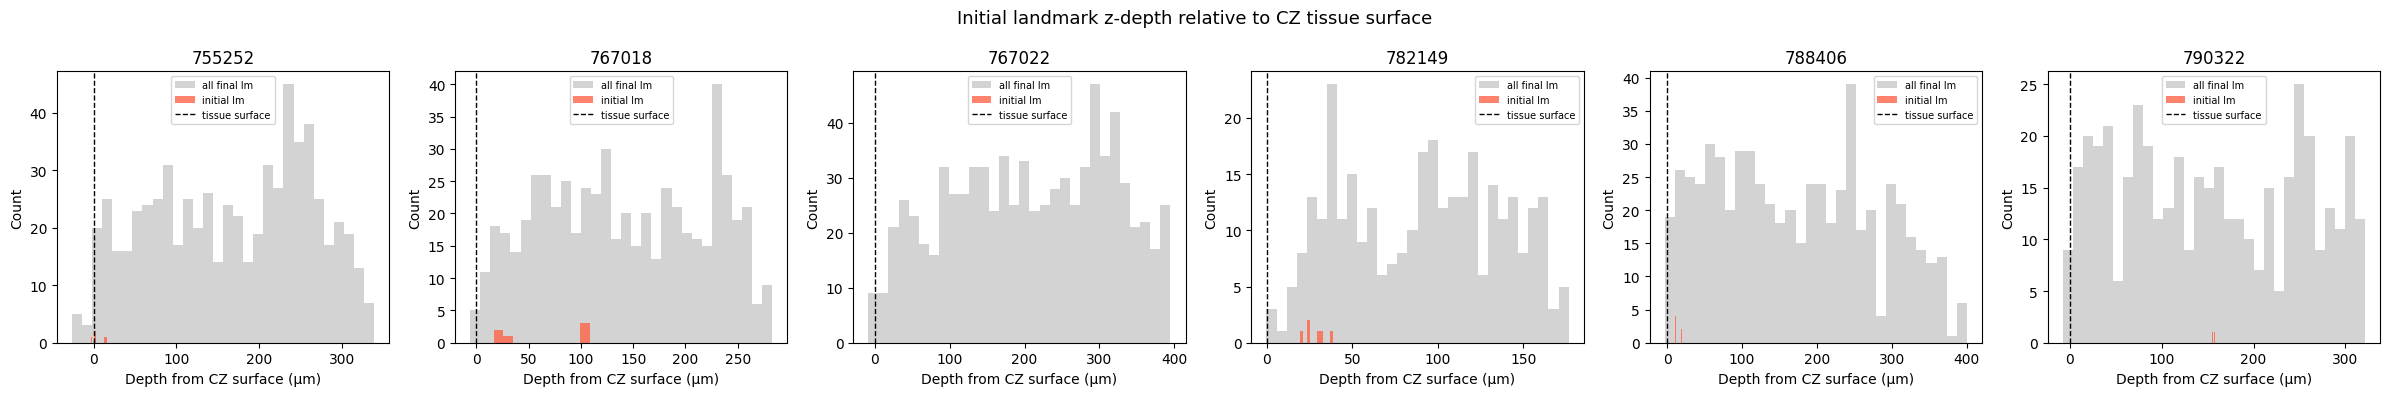

Initial constellation depth from CZ tissue surface (µm):
         n_init  init_z_min  init_z_max  init_z_mean
subject                                             
755252        5        -3.7        16.0          5.0
767018        6        16.7       108.3         62.3
767022        2       267.4       267.4        267.4
782149        6        19.3        38.7         27.6
788406        6        10.7        20.0         13.8
790322        4       155.2       157.6        156.6

Across subjects:
  depth range: -3.7 – 267.4 µm
  mean depth:  88.8 ± 103.5 µm


In [3]:
depth_rows = []

fig, axes = plt.subplots(1, len(data), figsize=(4*len(data), 4))
fig.suptitle('Initial landmark z-depth relative to CZ tissue surface', fontsize=13)

for i, (subj, d) in enumerate(data.items()):
    init = d['init']
    surf = d['cz_z_surface']
    if init is None or surf is None:
        continue

    depth_from_surface = init['cz_z_um'].values - surf
    final_depth = d['final']['cz_z_um'].values - surf

    depth_rows.append(dict(
        subject=subj,
        n_init=len(init),
        cz_z_surface=surf,
        init_z_min=depth_from_surface.min(),
        init_z_max=depth_from_surface.max(),
        init_z_mean=depth_from_surface.mean(),
    ))

    ax = axes[i]
    ax.hist(final_depth, bins=30, color='lightgrey', label='all final lm')
    ax.hist(depth_from_surface, bins=10, color='tomato', alpha=0.8, label='initial lm')
    ax.axvline(0, color='black', lw=1, ls='--', label='tissue surface')
    ax.set_xlabel('Depth from CZ surface (µm)')
    ax.set_ylabel('Count')
    ax.set_title(subj)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(SCRATCH / 'constellation_01_cz_depth.png', dpi=150)
plt.show()

depth_df = pd.DataFrame(depth_rows).set_index('subject')
print('Initial constellation depth from CZ tissue surface (µm):')
print(depth_df[['n_init','init_z_min','init_z_max','init_z_mean']].round(1))
print(f'\nAcross subjects:')
print(f'  depth range: {depth_df.init_z_min.min():.1f} – {depth_df.init_z_max.max():.1f} µm')
print(f'  mean depth:  {depth_df.init_z_mean.mean():.1f} ± {depth_df.init_z_mean.std():.1f} µm')

---
## 2. HCR Z-Spread of Initial Landmarks → MIP Window Size W

The initial constellation spans ~10 µm in CZ z (cells visible in a single
z-plane plus blur from adjacent slices). Their z-spread **in HCR coordinates**
measures the effective CZ axial PSF projected into HCR z units.
This is the optimal MIP window W for the rolling-MIP search step.

Initial constellation z-spread and implied MIP window:
         n_init  cz_z_spread_um  hcr_z_spread_um  z_scale_observed
subject                                                           
755252        5           19.70            52.73              2.68
767018        6           91.60           306.65              3.35
767022        2            0.00             0.53               NaN
782149        6           19.40            57.89              2.98
788406        6            9.28            17.99              1.94
790322        4            2.46            22.45              9.14


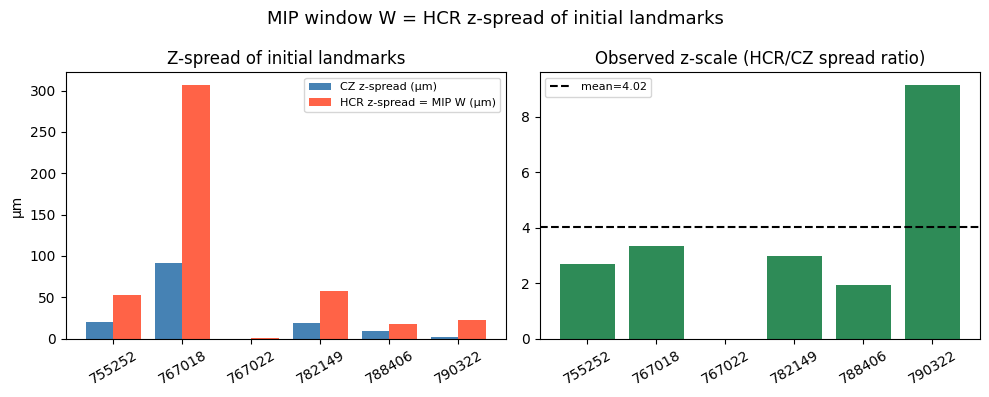


Recommended default MIP window W = 76.4 ± 114.9 µm


In [4]:
mip_rows = []

for subj, d in data.items():
    init = d['init']
    if init is None: continue

    hcr_z = init['hcr_z_um'].values
    cz_z  = init['cz_z_um'].values

    hcr_z_spread = hcr_z.max() - hcr_z.min()
    cz_z_spread  = cz_z.max()  - cz_z.min()

    mip_rows.append(dict(
        subject=subj,
        n_init=len(init),
        cz_z_spread_um=cz_z_spread,
        hcr_z_spread_um=hcr_z_spread,   # ← MIP window W
        z_scale_observed=hcr_z_spread / cz_z_spread if cz_z_spread > 0 else np.nan,
    ))

mip_df = pd.DataFrame(mip_rows).set_index('subject')
print('Initial constellation z-spread and implied MIP window:')
print(mip_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('MIP window W = HCR z-spread of initial landmarks', fontsize=13)

x = np.arange(len(mip_df))
ax = axes[0]
ax.bar(x - 0.2, mip_df['cz_z_spread_um'], 0.4, label='CZ z-spread (µm)', color='steelblue')
ax.bar(x + 0.2, mip_df['hcr_z_spread_um'], 0.4, label='HCR z-spread = MIP W (µm)', color='tomato')
ax.set_xticks(x); ax.set_xticklabels(mip_df.index, rotation=30)
ax.set_ylabel('µm'); ax.set_title('Z-spread of initial landmarks')
ax.legend(fontsize=8)

ax = axes[1]
ax.bar(x, mip_df['z_scale_observed'], color='seagreen')
ax.axhline(mip_df['z_scale_observed'].mean(), ls='--', color='black',
           label=f'mean={mip_df.z_scale_observed.mean():.2f}')
ax.set_xticks(x); ax.set_xticklabels(mip_df.index, rotation=30)
ax.set_title('Observed z-scale (HCR/CZ spread ratio)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(SCRATCH / 'constellation_02_mip_window.png', dpi=150)
plt.show()

W_mean = mip_df['hcr_z_spread_um'].mean()
W_std  = mip_df['hcr_z_spread_um'].std()
print(f'\nRecommended default MIP window W = {W_mean:.1f} ± {W_std:.1f} µm')

---
## 3. Constellation Geometry

For each subject: cell count, XY footprint area, inter-cell spacing,
convex hull area relative to full CZ XY area.

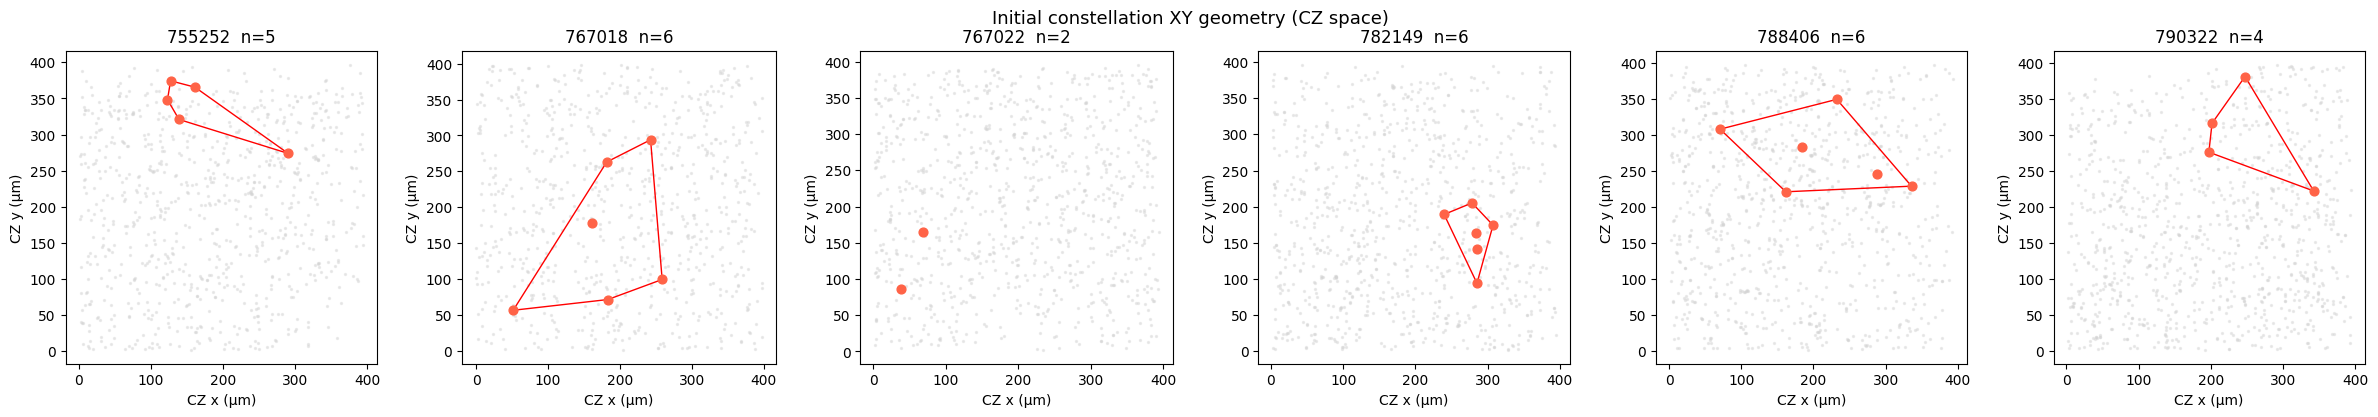

Constellation geometry:
         n_cells  nn_dist_mean  nn_dist_max  hull_area_um2  cz_xy_area_um2  \
subject                                                                      
755252         5         55.64       158.54        5031.09       154901.17   
767018         6         86.22       132.55       26051.95       157170.82   
767022         2         83.52        83.52            NaN       153600.74   
782149         6         33.70        47.07        3716.08       154238.97   
788406         6         72.07       116.33       19787.42       154350.29   
790322         4         78.67       154.90        9729.88       154345.66   

         hull_frac  
subject             
755252        0.03  
767018        0.17  
767022         NaN  
782149        0.02  
788406        0.13  
790322        0.06  

Mean hull fraction of CZ XY area: 0.083 ± 0.062
Mean NN distance: 68.3 ± 20.2 µm


In [5]:
geom_rows = []

fig, axes = plt.subplots(1, len(data), figsize=(4*len(data), 4))
fig.suptitle('Initial constellation XY geometry (CZ space)', fontsize=13)

for i, (subj, d) in enumerate(data.items()):
    init = d['init']
    cz   = d['cz']
    if init is None: continue

    xy = init[['cz_x_um', 'cz_y_um']].values

    # Pairwise distances
    dists = cdist(xy, xy)
    np.fill_diagonal(dists, np.nan)
    nn_dist = np.nanmin(dists, axis=1)  # nearest-neighbour distance

    # Convex hull area
    hull_area = np.nan
    if len(xy) >= 3:
        try:
            hull = ConvexHull(xy)
            hull_area = hull.volume  # in 2D, .volume is area
        except Exception:
            pass

    # Full CZ XY area
    if cz is not None:
        cz_xy_area = ((cz['czstack_x'].max() - cz['czstack_x'].min()) * CZ_RES_XY *
                      (cz['czstack_y'].max() - cz['czstack_y'].min()) * CZ_RES_XY)
    else:
        cz_xy_area = np.nan

    frac_area = hull_area / cz_xy_area if not np.isnan(hull_area) else np.nan

    geom_rows.append(dict(
        subject=subj,
        n_cells=len(init),
        nn_dist_mean=nn_dist.mean(),
        nn_dist_max=nn_dist.max(),
        hull_area_um2=hull_area,
        cz_xy_area_um2=cz_xy_area,
        hull_frac=frac_area,
    ))

    ax = axes[i]
    if cz is not None:
        ax.scatter(cz['czstack_x'].values*CZ_RES_XY,
                   cz['czstack_y'].values*CZ_RES_XY,
                   s=2, c='lightgrey', alpha=0.4)
    ax.scatter(xy[:, 0], xy[:, 1], s=40, c='tomato', zorder=3)
    if len(xy) >= 3 and not np.isnan(hull_area):
        hull = ConvexHull(xy)
        for simplex in hull.simplices:
            ax.plot(xy[simplex, 0], xy[simplex, 1], 'r-', lw=1)
    ax.set_title(f'{subj}  n={len(init)}')
    ax.set_xlabel('CZ x (µm)'); ax.set_ylabel('CZ y (µm)')
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig(SCRATCH / 'constellation_03_geometry.png', dpi=150)
plt.show()

geom_df = pd.DataFrame(geom_rows).set_index('subject')
print('Constellation geometry:')
print(geom_df.round(2))
print(f'\nMean hull fraction of CZ XY area: {geom_df.hull_frac.mean():.3f} ± {geom_df.hull_frac.std():.3f}')
print(f'Mean NN distance: {geom_df.nn_dist_mean.mean():.1f} ± {geom_df.nn_dist_mean.std():.1f} µm')

---
## 4. CZ Cell Density at the Constellation Depth

How many CZ cells are visible within a 10 µm z-window at the constellation depth?
Lower density = more distinctive constellations.

In [6]:
density_rows = []
Z_WINDOW_UM = 10.0

for subj, d in data.items():
    init = d['init']
    cz   = d['cz']
    surf = d['cz_z_surface']
    if init is None or cz is None or surf is None: continue

    # z-centre of constellation
    z_centre = init['cz_z_um'].mean()

    # Cells in ±Z_WINDOW_UM/2 around constellation
    cz_z = cz['czstack_z'].values * CZ_RES_Z
    in_window = np.abs(cz_z - z_centre) <= Z_WINDOW_UM / 2
    n_in_window = in_window.sum()

    # CZ XY area in µm²
    cz_xy_area = ((cz['czstack_x'].max() - cz['czstack_x'].min()) * CZ_RES_XY *
                  (cz['czstack_y'].max() - cz['czstack_y'].min()) * CZ_RES_XY)

    density_rows.append(dict(
        subject=subj,
        z_centre=z_centre,
        depth_from_surface=z_centre - surf,
        n_cells_in_window=n_in_window,
        density_per_um2=n_in_window / cz_xy_area,
    ))

density_df = pd.DataFrame(density_rows).set_index('subject')
print(f'CZ cell density within {Z_WINDOW_UM} µm z-window at constellation depth:')
print(density_df.round(4))

CZ cell density within 10.0 µm z-window at constellation depth:
         z_centre  depth_from_surface  n_cells_in_window  density_per_um2
subject                                                                  
755252    75.6192              5.0454                 22           0.0001
767018   100.7562             62.2562                 34           0.0002
767022   315.8902            267.3750                 22           0.0001
782149    61.9576             27.6371                 24           0.0002
788406    59.0118             13.7927                 12           0.0001
790322   210.5341            156.5536                 31           0.0002


---
## 5. Summary — Pipeline Parameters

In [7]:
print('=' * 55)
print('INITIAL CONSTELLATION — PIPELINE PARAMETERS')
print('=' * 55)
print(f'CZ search depth (from tissue surface):')
print(f'  {depth_df.init_z_min.min():.0f} – {depth_df.init_z_max.max():.0f} µm  '
      f'(mean {depth_df.init_z_mean.mean():.0f} µm)')
print()
print(f'Default MIP window W (HCR z-spread of initial lm):')
print(f'  {W_mean:.1f} ± {W_std:.1f} µm  '
      f'range [{mip_df.hcr_z_spread_um.min():.1f}, {mip_df.hcr_z_spread_um.max():.1f}]')
print()
print(f'Constellation cell count:  {geom_df.n_cells.mean():.1f} ± {geom_df.n_cells.std():.1f}')
print(f'NN spacing (µm):           {geom_df.nn_dist_mean.mean():.1f} ± {geom_df.nn_dist_mean.std():.1f}')
print(f'Hull fraction of CZ area:  {geom_df.hull_frac.mean():.3f} ± {geom_df.hull_frac.std():.3f}')
print()
print('Figures saved to /scratch/constellation_0*.png')

# Save
out = pd.concat([depth_df[['n_init','init_z_min','init_z_max','init_z_mean']],
                 mip_df[['hcr_z_spread_um','z_scale_observed']],
                 geom_df[['n_cells','nn_dist_mean','hull_frac']]], axis=1)
out.to_csv(DATA_DIR / 'constellation_analysis_summary.csv')
print(f'Saved: {DATA_DIR}/constellation_analysis_summary.csv')

INITIAL CONSTELLATION — PIPELINE PARAMETERS
CZ search depth (from tissue surface):
  -4 – 267 µm  (mean 89 µm)

Default MIP window W (HCR z-spread of initial lm):
  76.4 ± 114.9 µm  range [0.5, 306.6]

Constellation cell count:  4.8 ± 1.6
NN spacing (µm):           68.3 ± 20.2
Hull fraction of CZ area:  0.083 ± 0.062

Figures saved to /scratch/constellation_0*.png
Saved: /root/capsule/data/constellation_analysis_summary.csv
